# StockBot: Dual-Input LSTM — Sentiment + Price Forecasting
Extends the vanilla LSTM baseline with a **sentiment signal** sourced from daily FinBERT-scored news headlines.
Three fusion strategies are compared — Concatenation, Cross-Attention, and Gating — each merging an independent
price LSTM and a sentiment LSTM before the regression head.
Training follows the same sliding-window protocol (60-day input → 1-day-ahead output) with Adam, MSE loss, and early stopping.
Results are reported for **AAPL**, **MSFT**, and **BRK-A**.

In [1]:
%pip install -q torch numpy scikit-learn matplotlib pandas yfinance

Note: you may need to restart the kernel to use updated packages.


## 0. Dataset Setup
Downloads the AAPL CSV from GitHub if not available locally (e.g. on Colab).
MSFT and BRK-A prices are fetched directly from Yahoo Finance; MSFT sentiment is merged from a local CSV where available.

In [2]:
import os, urllib.request

AAPL_CSV  = 'aapl_daily_sentiment_2021_2025.csv'
RAW_URL   = ('https://raw.githubusercontent.com/franciscomartinez45/'
             'Stock-Forecasting-LSTM/main/data/processed/' + AAPL_CSV)
AAPL_PATHS = [
    f'../data/processed/{AAPL_CSV}',
    f'data/processed/{AAPL_CSV}',
    AAPL_CSV,
]

aapl_csv_path = next((p for p in AAPL_PATHS if os.path.exists(p)), None)
if aapl_csv_path is None:
    print('Downloading AAPL dataset from GitHub...')
    urllib.request.urlretrieve(RAW_URL, AAPL_CSV)
    aapl_csv_path = AAPL_CSV
    print('Done.')
else:
    print(f'AAPL dataset found locally: {aapl_csv_path}')

MSFT_PATHS = [
    '../data/processed/msft_daily_sentiment_2023.csv',
    'data/processed/msft_daily_sentiment_2023.csv',
]
msft_csv_path = next((p for p in MSFT_PATHS if os.path.exists(p)), None)
print(f'MSFT sentiment CSV: {msft_csv_path if msft_csv_path else "not found — MSFT will use neutral sentiment"}')

os.makedirs('plots', exist_ok=True)

AAPL dataset found locally: ../data/processed/aapl_daily_sentiment_2021_2025.csv
MSFT sentiment CSV: ../data/processed/msft_daily_sentiment_2023.csv


## 1. Imports & Config

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

np.random.seed(42)
torch.manual_seed(42)

# ── Hyperparameters ────────────────────────────────────────────────────────
TICKERS      = ['AAPL', 'MSFT', 'BRK-A']
START_DATE   = '2021-05-01'
END_DATE     = '2025-12-31'
PAST_HISTORY = 60
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 1e-3
PATIENCE     = 15
TRAIN_RATIO  = 0.8
VAL_RATIO    = 0.1

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Data Loading
- **AAPL**: prices and sentiment (`avg_positive − avg_negative`) loaded from the pre-processed CSV.
- **MSFT**: prices from Yahoo Finance (2021–2025); sentiment merged from the 2023 sentiment CSV where available, 0 elsewhere.
- **BRK-A**: prices from Yahoo Finance (2021–2025); sentiment set to 0 (neutral) — no sentiment data available.

All scalers are fit on training data only to prevent leakage.

In [4]:
def load_ticker_data(ticker):
    """Return (prices, sentiments, dates) arrays for the configured date window."""

    # ── AAPL: full CSV available ──────────────────────────────────────────
    if ticker == 'AAPL' and aapl_csv_path:
        df = pd.read_csv(aapl_csv_path, parse_dates=['date'])
        df = df[(df['date'] >= START_DATE) & (df['date'] <= END_DATE)].reset_index(drop=True)
        prices     = df['close'].values.astype(np.float32)
        sentiments = (df['avg_positive'] - df['avg_negative']).values.astype(np.float32)
        dates      = df['date'].tolist()
        print(f'AAPL: {len(prices)} days from CSV ({dates[0].date()} → {dates[-1].date()})')
        return prices, np.clip(sentiments, -1, 1), dates

    # ── Other tickers: prices from yfinance ───────────────────────────────
    raw = yf.download(ticker, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.index = pd.to_datetime(raw.index).tz_localize(None)
    df_price = raw[['Close']].rename(columns={'Close': 'close'}).reset_index()
    df_price.columns = ['date', 'close']

    # ── MSFT: partial 2023 sentiment available ────────────────────────────
    if ticker == 'MSFT' and msft_csv_path:
        df_sent = pd.read_csv(msft_csv_path, parse_dates=['date'])
        df_sent['date'] = pd.to_datetime(df_sent['date'])
        df = df_price.merge(df_sent[['date', 'avg_positive', 'avg_negative']], on='date', how='left')
        df['sentiment'] = np.where(
            df['avg_positive'].notna(),
            df['avg_positive'] - df['avg_negative'],
            0.0,
        )
        sent_days = df['avg_positive'].notna().sum()
    else:
        df = df_price.copy()
        df['sentiment'] = 0.0
        sent_days = 0

    prices     = df['close'].values.astype(np.float32)
    sentiments = np.clip(df['sentiment'].values.astype(np.float32), -1, 1)
    dates      = df['date'].tolist()
    print(f'{ticker}: {len(prices)} days | {sent_days} days with sentiment ({dates[0].date()} → {dates[-1].date()})')
    return prices, sentiments, dates

## 3. Dataset & DataLoaders
Each sample: 60-day price window + 60-day sentiment window → next-day price target.

In [5]:
class SentimentPriceDataset(Dataset):
    def __init__(self, prices_sc, sentiments_sc):
        self.p = torch.tensor(prices_sc,     dtype=torch.float32)
        self.s = torch.tensor(sentiments_sc, dtype=torch.float32)

    def __len__(self):
        return len(self.p) - PAST_HISTORY

    def __getitem__(self, idx):
        return (
            self.p[idx : idx + PAST_HISTORY].unsqueeze(-1),
            self.s[idx : idx + PAST_HISTORY].unsqueeze(-1),
            self.p[idx + PAST_HISTORY],
        )


def make_loaders(prices_sc, sentiments_sc, train_end, val_end):
    train_ds = SentimentPriceDataset(prices_sc[:train_end],
                                     sentiments_sc[:train_end])
    val_ds   = SentimentPriceDataset(prices_sc[train_end - PAST_HISTORY : val_end],
                                     sentiments_sc[train_end - PAST_HISTORY : val_end])
    test_ds  = SentimentPriceDataset(prices_sc[val_end - PAST_HISTORY :],
                                     sentiments_sc[val_end - PAST_HISTORY :])
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, val_loader, test_loader


print('SentimentPriceDataset and make_loaders defined.')

SentimentPriceDataset and make_loaders defined.


## 4. Model Architectures — Three Fusion Strategies
Each architecture encodes price and sentiment independently with an LSTM, then fuses the representations:

1. **Concatenation** — hidden states concatenated → two-layer FC head.
2. **Cross-Attention** — price queries attend over the full sentiment sequence before the FC head.
3. **Gating** — a learned sigmoid gate controls how much sentiment modulates the price representation.

In [6]:
# ── Strategy 1: Concatenation ──────────────────────────────────────────────
class DualInputConcat(nn.Module):
    def __init__(self, price_hidden=64, sentiment_hidden=32, fusion_dim=64, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, price_hidden,     num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, sentiment_hidden, num_layers=1, batch_first=True)
        self.fusion = nn.Sequential(
            nn.Linear(price_hidden + sentiment_hidden, fusion_dim),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(fusion_dim, 1),
        )

    def forward(self, prices, sentiments):
        _, (h_p, _) = self.price_lstm(prices)
        _, (h_s, _) = self.sentiment_lstm(sentiments)
        return self.fusion(torch.cat([h_p[-1], h_s[-1]], dim=-1)).squeeze(-1)


# ── Strategy 2: Cross-Attention ────────────────────────────────────────────
class DualInputAttention(nn.Module):
    def __init__(self, hidden_dim=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=num_heads, batch_first=True, dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, prices, sentiments):
        price_enc, _     = self.price_lstm(prices)
        sentiment_enc, _ = self.sentiment_lstm(sentiments)
        attn_out, _ = self.cross_attn(price_enc[:, -1:, :], sentiment_enc, sentiment_enc)
        return self.fc(attn_out[:, 0, :]).squeeze(-1)


# ── Strategy 3: Gating ─────────────────────────────────────────────────────
class DualInputGating(nn.Module):
    def __init__(self, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.price_lstm     = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.sentiment_lstm = nn.LSTM(1, hidden_dim, num_layers=1, batch_first=True)
        self.gate_fc  = nn.Linear(2 * hidden_dim, hidden_dim)
        self.merge_fc = nn.Linear(2 * hidden_dim, hidden_dim)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, prices, sentiments):
        _, (h_p, _) = self.price_lstm(prices)
        _, (h_s, _) = self.sentiment_lstm(sentiments)
        cat   = torch.cat([h_p[-1], h_s[-1]], dim=-1)
        gate  = torch.sigmoid(self.gate_fc(cat))
        merge = torch.tanh(self.merge_fc(cat))
        return self.fc(gate * merge).squeeze(-1)


print('Model architectures defined: Concat, Attention, Gating')

Model architectures defined: Concat, Attention, Gating


## 5. Training & Evaluation Infrastructure
Shared training loop (Adam + MSE + early stopping) and helper functions used by all three tickers.

In [7]:
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val, p_count = float('inf'), 0
    tr_losses, vl_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        tr = 0.0
        for p, s, y in train_loader:
            p, s, y = p.to(DEVICE), s.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(p, s), y)
            loss.backward()
            optimizer.step()
            tr += loss.item()

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for p, s, y in val_loader:
                vl += criterion(model(p.to(DEVICE), s.to(DEVICE)), y.to(DEVICE)).item()

        tr_losses.append(tr / len(train_loader))
        vl_losses.append(vl / max(len(val_loader), 1))

        if vl_losses[-1] < best_val:
            best_val, p_count = vl_losses[-1], 0
        else:
            p_count += 1
            if p_count >= patience:
                print(f'    Early stop at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'    Epoch {epoch:3d} | Train {tr_losses[-1]:.5f} | Val {vl_losses[-1]:.5f}')

    return tr_losses, vl_losses


@torch.no_grad()
def sliding_window_forecast(model, prices_sc, sentiments_sc, n_steps, offset):
    model.eval()
    preds = []
    for i in range(n_steps):
        start = offset - PAST_HISTORY + i
        p_win = torch.tensor(prices_sc[start : start + PAST_HISTORY],
                             dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        s_win = torch.tensor(sentiments_sc[start : start + PAST_HISTORY],
                             dtype=torch.float32).view(1, PAST_HISTORY, 1).to(DEVICE)
        preds.append(model(p_win, s_win).item())
    return np.array(preds)


def stockbot_portfolio(prices, capital=100.0):
    delta = np.sign(np.diff(prices)).astype(int)
    Delta = np.diff(delta)
    held, buy_price, cur = False, 0.0, capital
    portfolio = [cur]
    for i, d in enumerate(Delta):
        sp = prices[i + 1]
        if d == 2 and not held:
            held, buy_price = True, sp
        elif d == -2 and held:
            held = False
            cur *= sp / buy_price
        portfolio.append(cur)
    portfolio.append(cur)
    return np.array(portfolio)


def compute_metrics(preds, actual):
    rmse = np.sqrt(np.mean((preds - actual) ** 2))
    mae  = np.mean(np.abs(preds - actual))
    mape = np.mean(np.abs((preds - actual) / actual)) * 100
    return rmse, mae, mape


print('Training and evaluation helpers defined.')

Training and evaluation helpers defined.


## 6. Experiments
For each ticker the full pipeline runs end-to-end:
load → scale → train three fusion models → plot training curves → sliding-window forecast → prediction error → StockBot portfolio → metrics table.

In [8]:
all_results = {}

def run_ticker(ticker):
    print(f'\n{"="*62}')
    print(f'  {ticker}')
    print(f'{"="*62}')

    # ── Data ──────────────────────────────────────────────────────────────
    prices, sentiments, dates = load_ticker_data(ticker)
    n         = len(prices)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))
    n_test    = n - val_end

    scaler_p = StandardScaler().fit(prices[:train_end].reshape(-1, 1))
    scaler_s = StandardScaler().fit(sentiments[:train_end].reshape(-1, 1))
    prices_sc     = scaler_p.transform(prices.reshape(-1, 1)).flatten()
    sentiments_sc = scaler_s.transform(sentiments.reshape(-1, 1)).flatten()

    print(f'  Split — Train: {train_end} | Val: {val_end - train_end} | Test: {n_test}')

    train_loader, val_loader, _ = make_loaders(prices_sc, sentiments_sc, train_end, val_end)

    # ── Train ─────────────────────────────────────────────────────────────
    torch.manual_seed(42)
    model_c = DualInputConcat().to(DEVICE)
    model_a = DualInputAttention().to(DEVICE)
    model_g = DualInputGating().to(DEVICE)

    print('\n  Training Concatenation...')
    tr_c, vl_c = train_model(model_c, train_loader, val_loader)
    print('  Training Cross-Attention...')
    tr_a, vl_a = train_model(model_a, train_loader, val_loader)
    print('  Training Gating...')
    tr_g, vl_g = train_model(model_g, train_loader, val_loader)

    # ── Training curves ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, tr, vl) in zip(axes, [
        ('Concatenation',   tr_c, vl_c),
        ('Cross-Attention', tr_a, vl_a),
        ('Gating',          tr_g, vl_g),
    ]):
        ax.plot(tr, label='Train')
        ax.plot(vl, label='Val')
        ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f'{ticker} — Training Loss', y=1.01)
    plt.tight_layout()
    plt.savefig(f'plots/{ticker}_dual_training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Forecast ──────────────────────────────────────────────────────────
    inv    = lambda x: scaler_p.inverse_transform(x.reshape(-1, 1)).flatten()
    actual = inv(prices_sc[val_end:])

    preds_c = inv(sliding_window_forecast(model_c, prices_sc, sentiments_sc, n_test, val_end))
    preds_a = inv(sliding_window_forecast(model_a, prices_sc, sentiments_sc, n_test, val_end))
    preds_g = inv(sliding_window_forecast(model_g, prices_sc, sentiments_sc, n_test, val_end))

    plt.figure(figsize=(12, 4))
    plt.plot(actual,  color='black', label=f'{ticker} Ground Truth', linewidth=1.5)
    plt.plot(preds_c, color='blue',  label='Concat',    linestyle='--', alpha=0.7)
    plt.plot(preds_a, color='red',   label='Attention', linestyle='--', alpha=0.7)
    plt.plot(preds_g, color='green', label='Gating',    linestyle='--', alpha=0.7)
    plt.title(f'One-Day-Ahead Forecasting — {ticker} (Dual-Input)')
    plt.xlabel('Trading Days'); plt.ylabel('Price ($)'); plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{ticker}_dual_forecast.png', dpi=150)
    plt.show()

    # ── Prediction error ──────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    for ax, (name, preds, color) in zip(axes, [
        ('Concatenation',   preds_c, 'blue'),
        ('Cross-Attention', preds_a, 'red'),
        ('Gating',          preds_g, 'green'),
    ]):
        pct = (preds - actual) / actual * 100
        ax.plot(pct, color=color, linewidth=1)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1)
        ax.set_ylabel('Error (%)'); ax.grid(True, alpha=0.3)
        ax.set_title(f'{name} — Mean: {pct.mean():.2f}% | Max: {pct.max():.2f}% | Min: {pct.min():.2f}%')
    axes[-1].set_xlabel('Trading Days')
    plt.suptitle(f'Prediction Error — {ticker} (Dual-Input vs Ground Truth)', y=1.01)
    plt.tight_layout()
    plt.savefig(f'plots/{ticker}_dual_prediction_error.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Portfolio ─────────────────────────────────────────────────────────
    port_gt = stockbot_portfolio(actual)
    port_c  = stockbot_portfolio(preds_c)
    port_a  = stockbot_portfolio(preds_a)
    port_g  = stockbot_portfolio(preds_g)

    plt.figure(figsize=(12, 4))
    plt.plot(port_gt, color='black', label=f'{ticker} Ground Truth', linewidth=1.5)
    plt.plot(port_c,  color='blue',  label='Concat Portfolio',   linestyle='--', alpha=0.8)
    plt.plot(port_a,  color='red',   label='Attention Portfolio', linestyle='--', alpha=0.8)
    plt.plot(port_g,  color='green', label='Gating Portfolio',   linestyle='--', alpha=0.8)
    plt.axhline(100, color='gray', linestyle=':', label='Initial ($100)')
    plt.ticklabel_format(useOffset=False, style='plain')
    plt.title(f'Portfolio — {ticker} (Dual-Input Strategies)')
    plt.xlabel('Trading Days'); plt.ylabel('Value ($)'); plt.legend()
    plt.tight_layout()
    plt.savefig(f'plots/{ticker}_dual_portfolio.png', dpi=150)
    plt.show()

    print(f'  Portfolio — GT: ${port_gt[-1]:.2f} | Concat: ${port_c[-1]:.2f} | '
          f'Attention: ${port_a[-1]:.2f} | Gating: ${port_g[-1]:.2f}')

    # ── Metrics ───────────────────────────────────────────────────────────
    results = {
        'Concatenation':   compute_metrics(preds_c, actual),
        'Cross-Attention': compute_metrics(preds_a, actual),
        'Gating':          compute_metrics(preds_g, actual),
    }
    print(f'\n  {"─"*52}')
    print(f'  {"Model":<22} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
    print(f'  {"─"*52}')
    for name, (r, m, mp) in results.items():
        print(f'  {name:<22} ${r:>6.2f}  ${m:>6.2f}  {mp:>6.2f}%')
    print(f'  {"─"*52}')

    return results

### AAPL (Apple Inc.)
Full FinBERT sentiment signal available for the entire 2021–2025 window.


  AAPL
AAPL: 1160 days from CSV (2021-05-03 → 2025-12-26)
  Split — Train: 928 | Val: 116 | Test: 116

  Training Concatenation...


    Epoch  10 | Train 0.02107 | Val 0.05493


    Epoch  20 | Train 0.01684 | Val 0.04158


    Epoch  30 | Train 0.01505 | Val 0.03373


    Epoch  40 | Train 0.01545 | Val 0.03223


...

    Epoch  40 | Train 0.01975 | Val 0.03768


    Epoch  50 | Train 0.01848 | Val 0.02797


    Epoch  60 | Train 0.01675 | Val 0.02632


    Epoch  70 | Train 0.01771 | Val 0.03033


    Early stop at epoch 75


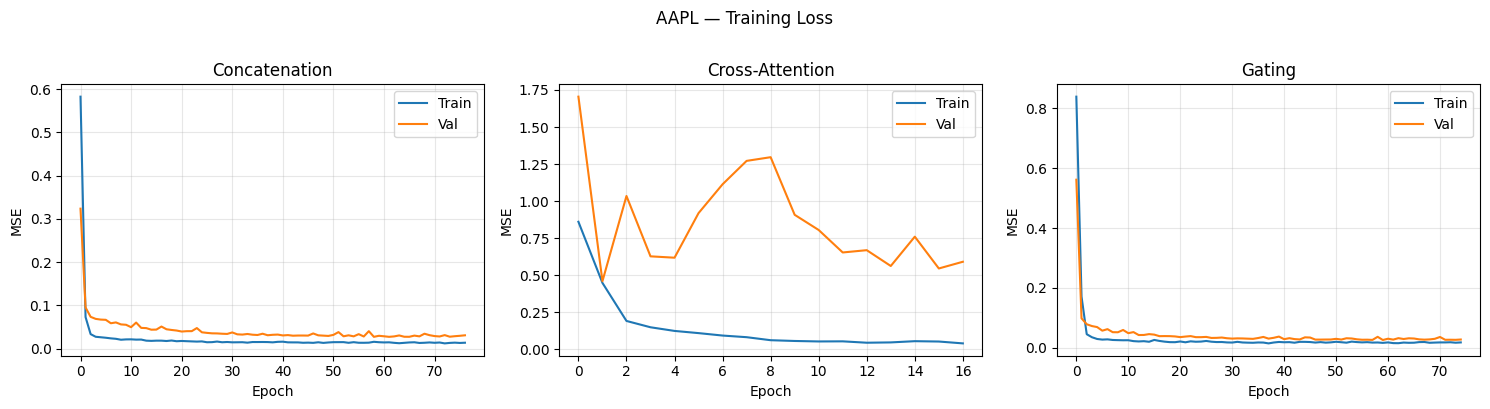

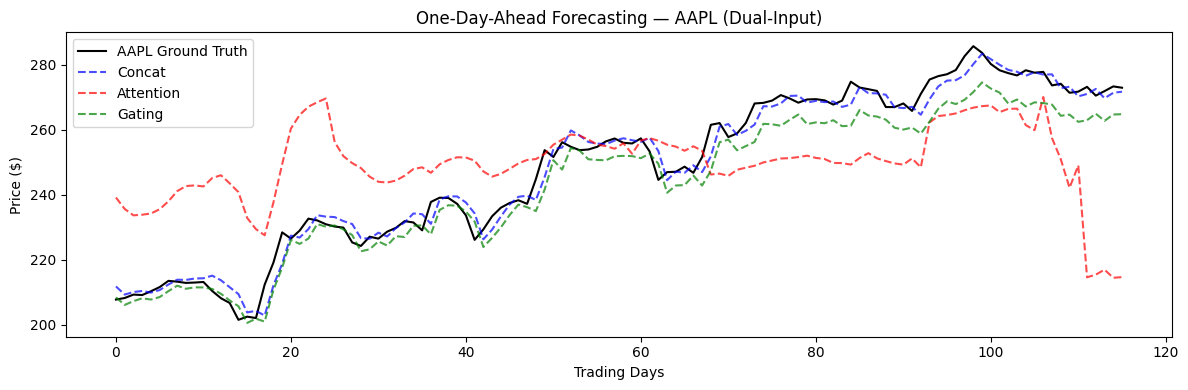

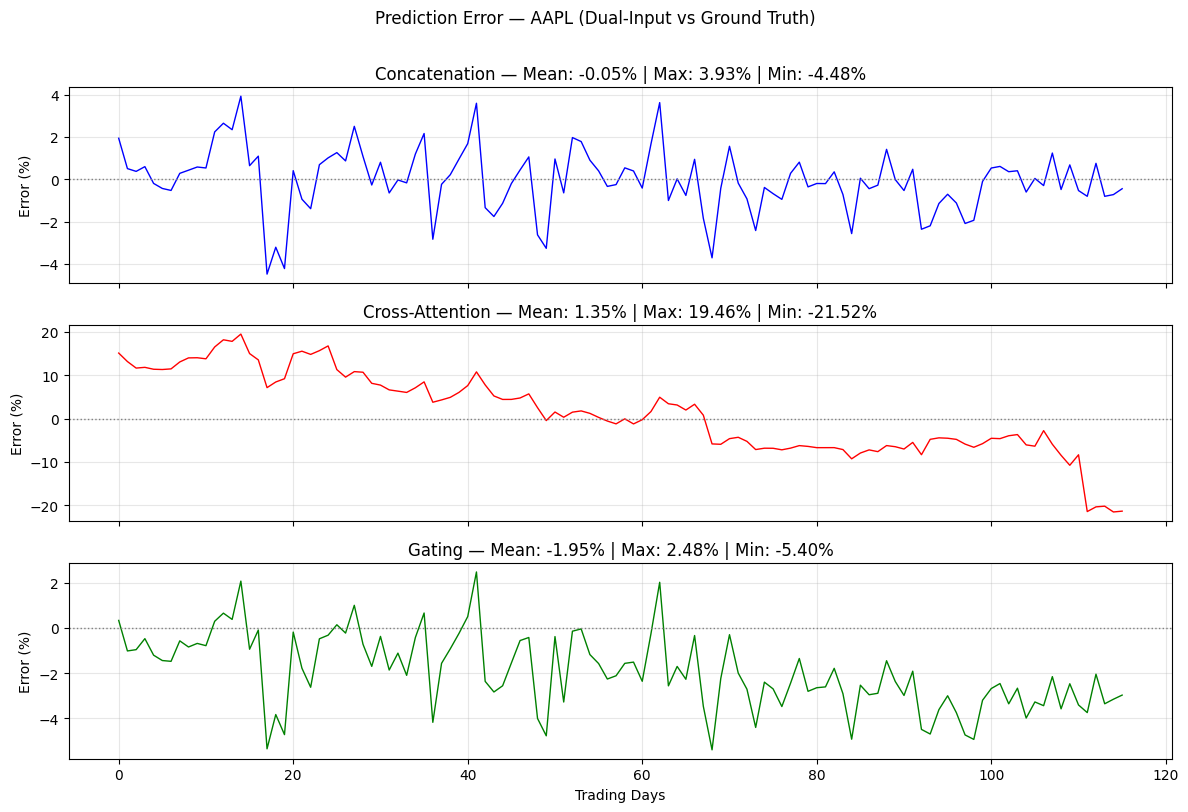

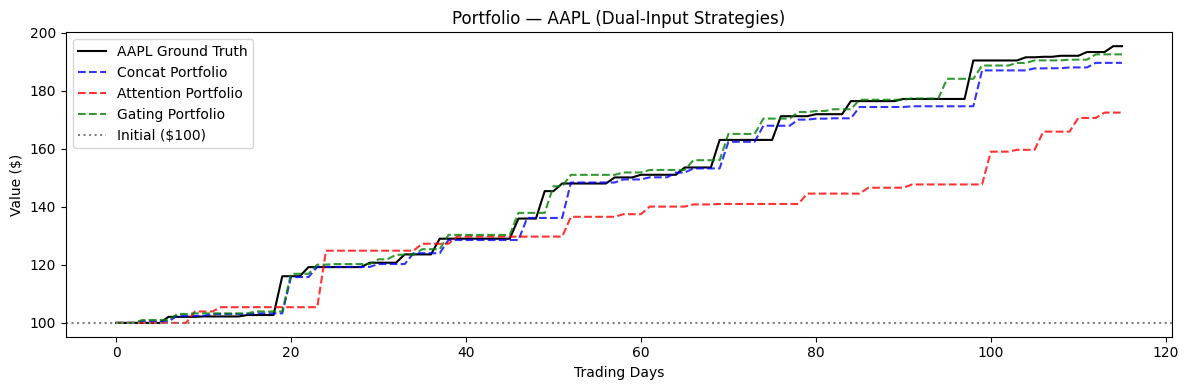

  Portfolio — GT: $195.40 | Concat: $189.65 | Attention: $172.50 | Gating: $192.58

  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $  3.55  $  2.67    1.10%
  Cross-Attention        $ 22.61  $ 19.01    7.85%
  Gating                 $  6.65  $  5.49    2.14%
  ────────────────────────────────────────────────────


In [9]:
all_results['AAPL'] = run_ticker('AAPL')

### MSFT (Microsoft Corporation)
Prices from Yahoo Finance (2021–2025). FinBERT sentiment merged from the 2023 CSV; trading days outside 2023 use neutral sentiment (0).


  MSFT


MSFT: 1172 days | 249 days with sentiment (2021-05-03 → 2025-12-30)
  Split — Train: 937 | Val: 117 | Test: 118

  Training Concatenation...


    Epoch  10 | Train 0.01864 | Val 0.06577


    Epoch  20 | Train 0.01391 | Val 0.02899


    Epoch  30 | Train 0.01351 | Val 0.02363


...

    Epoch  40 | Train 0.01575 | Val 0.01829


    Epoch  50 | Train 0.01546 | Val 0.01412


    Epoch  60 | Train 0.01601 | Val 0.02285


    Epoch  70 | Train 0.01587 | Val 0.01403


    Early stop at epoch 73


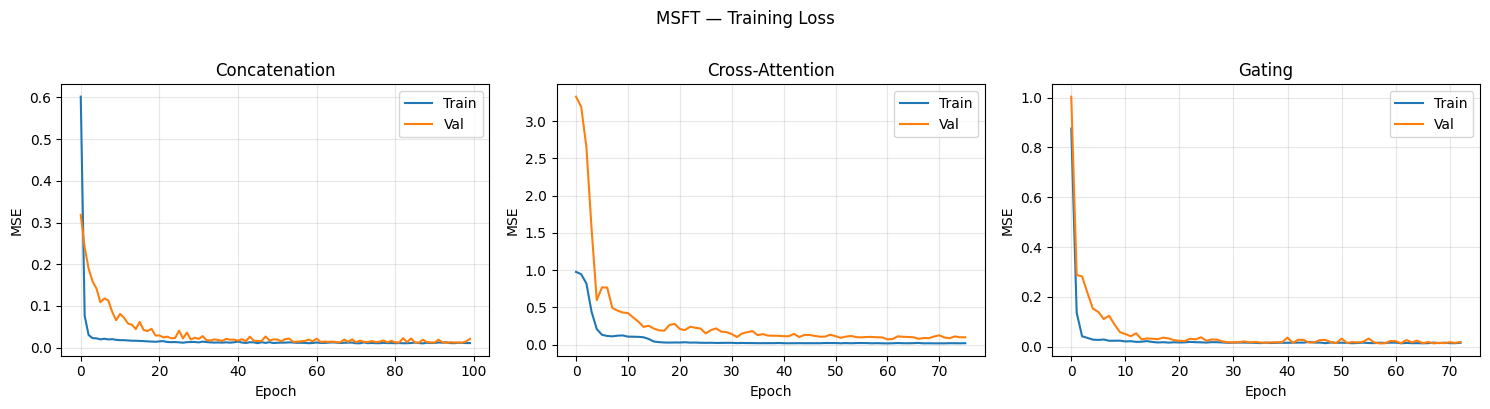

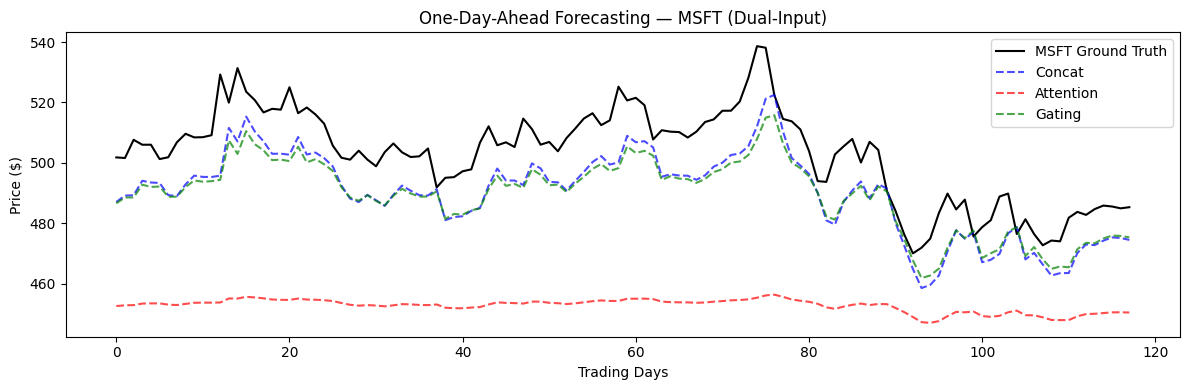

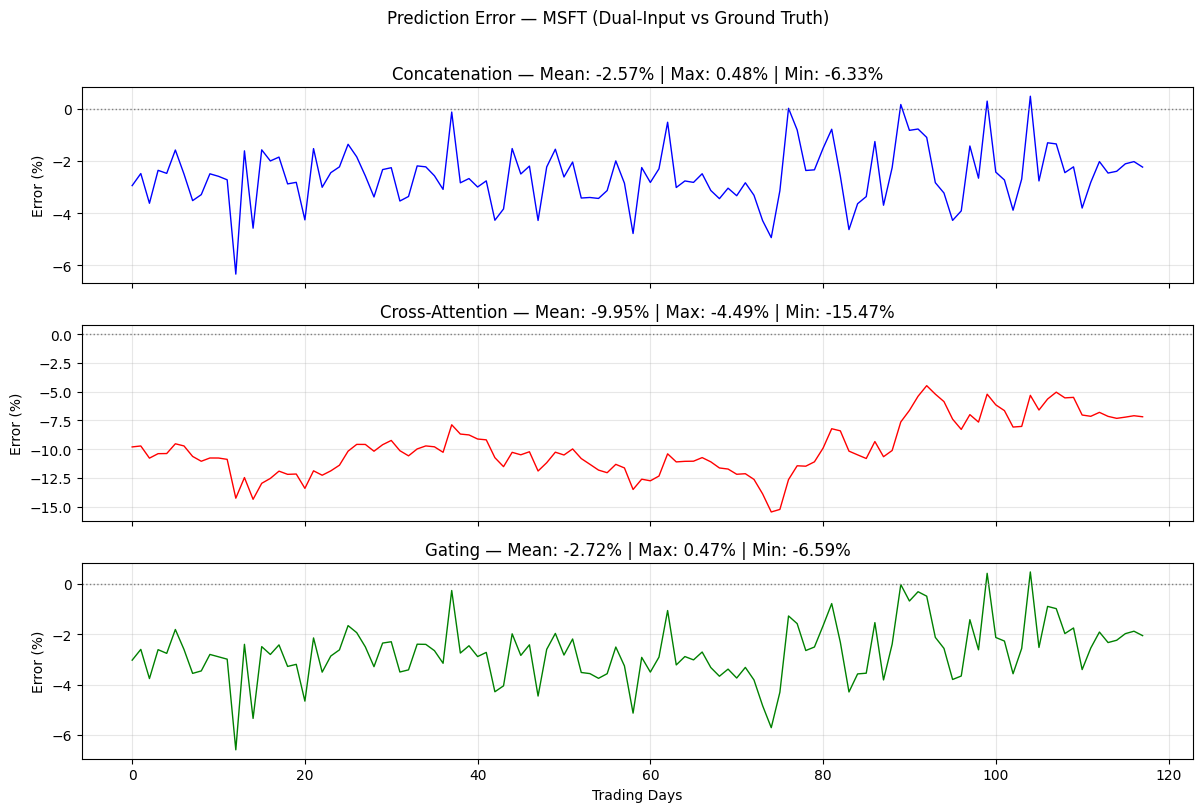

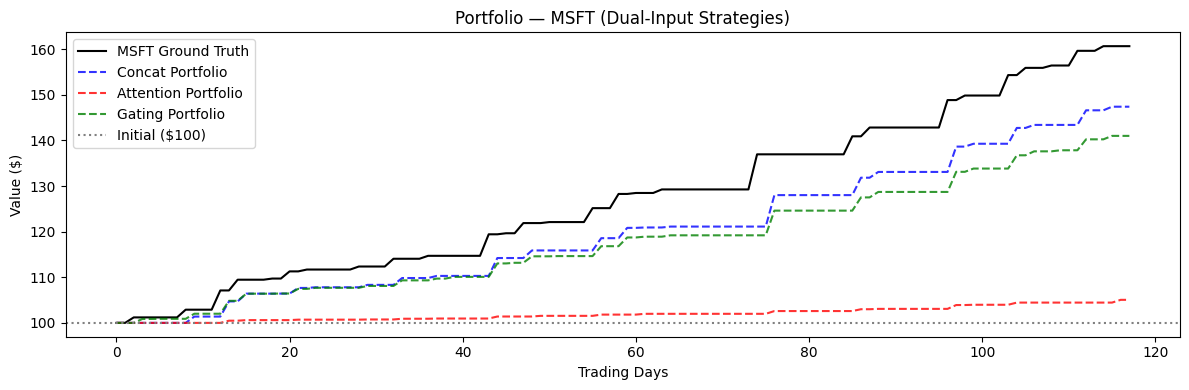

  Portfolio — GT: $160.67 | Concat: $147.40 | Attention: $105.05 | Gating: $141.00

  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $ 14.20  $ 13.07    2.58%
  Cross-Attention        $ 52.15  $ 50.42    9.95%
  Gating                 $ 15.09  $ 13.88    2.74%
  ────────────────────────────────────────────────────


In [10]:
all_results['MSFT'] = run_ticker('MSFT')

### BRK-A (Berkshire Hathaway Class A)
Prices from Yahoo Finance (2021–2025). No sentiment data available; sentiment input is set to neutral (0) throughout.


  BRK-A


BRK-A: 1172 days | 0 days with sentiment (2021-05-03 → 2025-12-30)
  Split — Train: 937 | Val: 117 | Test: 118

  Training Concatenation...


    Epoch  10 | Train 0.01600 | Val 0.03951


    Epoch  20 | Train 0.01413 | Val 0.02223


    Epoch  30 | Train 0.01177 | Val 0.01879


...

    Epoch  40 | Train 0.01578 | Val 0.05063


    Epoch  50 | Train 0.01323 | Val 0.02034


    Epoch  60 | Train 0.01695 | Val 0.01349


    Epoch  70 | Train 0.01442 | Val 0.05700


    Early stop at epoch 75


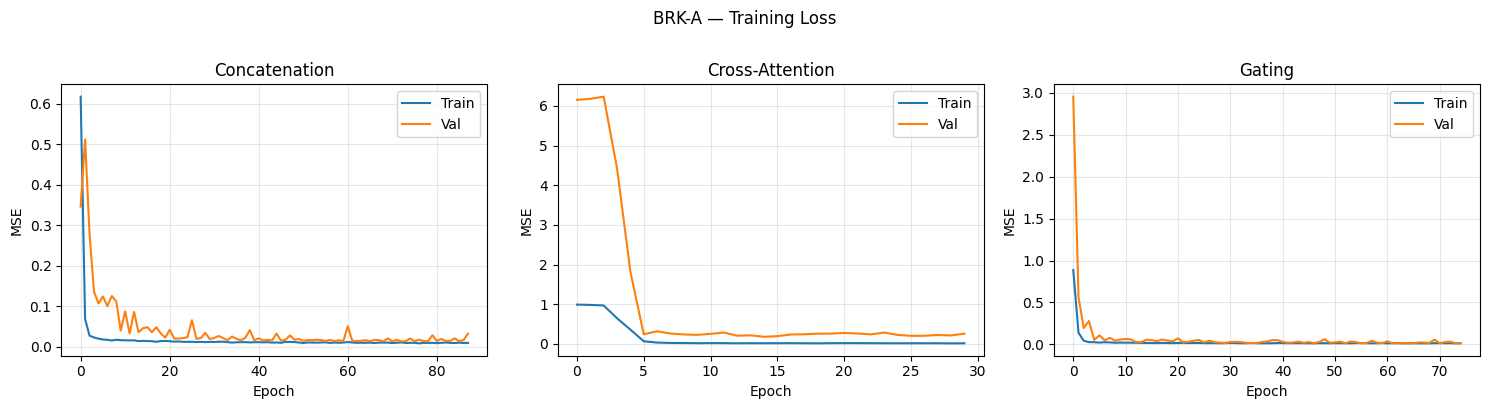

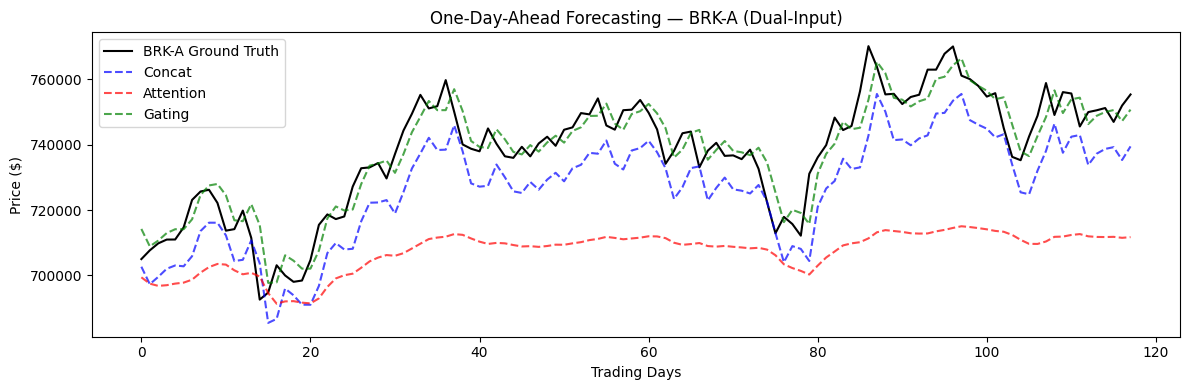

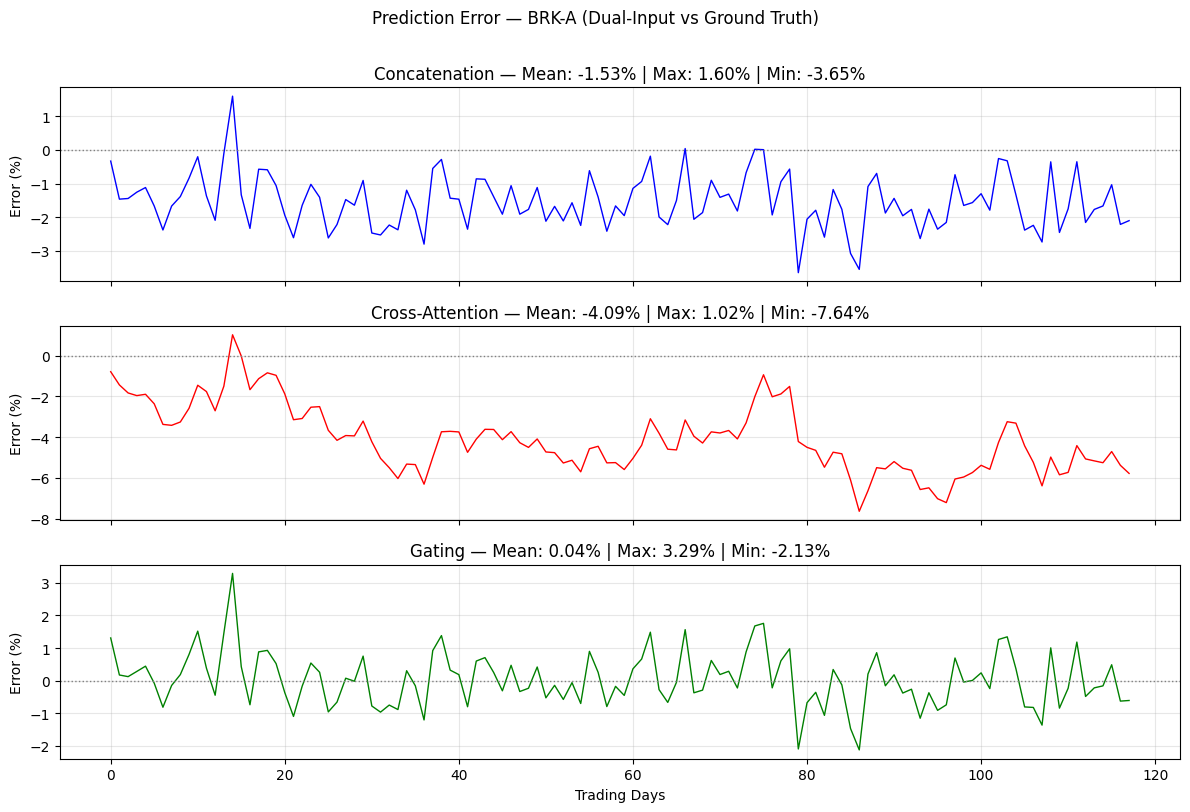

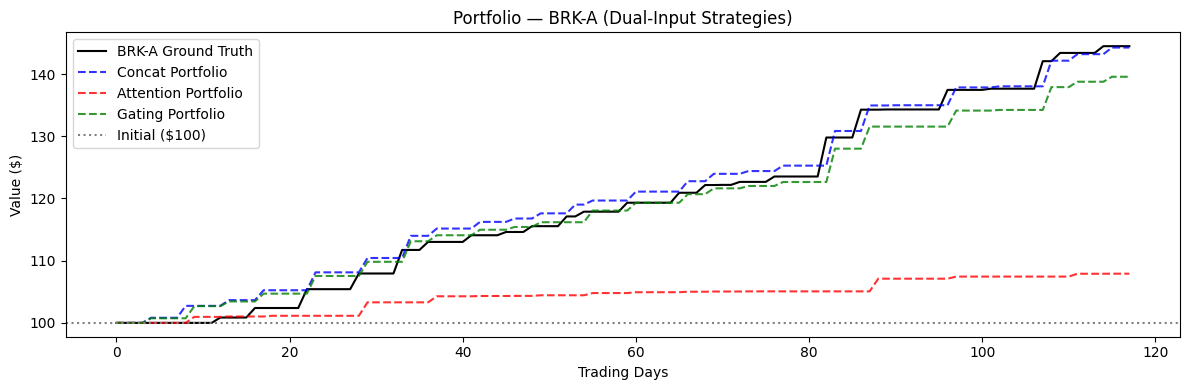

  Portfolio — GT: $144.49 | Concat: $144.27 | Attention: $107.91 | Gating: $139.57

  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $12846.97  $11528.70    1.56%
  Cross-Attention        $33010.61  $30608.20    4.11%
  Gating                 $6073.76  $4757.31    0.65%
  ────────────────────────────────────────────────────


In [11]:
all_results['BRK-A'] = run_ticker('BRK-A')

## 7. Cross-Ticker Metrics Summary
RMSE, MAE, and MAPE for every fusion strategy across all three tickers.

In [12]:
print(f'\n{"="*62}')
print('  CROSS-TICKER METRICS SUMMARY')
print(f'{"="*62}')
for ticker, results in all_results.items():
    print(f'\n  {ticker}')
    print(f'  {"─"*52}')
    print(f'  {"Model":<22} {"RMSE":>8} {"MAE":>8} {"MAPE":>8}')
    print(f'  {"─"*52}')
    for name, (r, m, mp) in results.items():
        print(f'  {name:<22} ${r:>6.2f}  ${m:>6.2f}  {mp:>6.2f}%')
    print(f'  {"─"*52}')
print(f'\n{"="*62}')


  CROSS-TICKER METRICS SUMMARY

  AAPL
  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $  3.55  $  2.67    1.10%
  Cross-Attention        $ 22.61  $ 19.01    7.85%
  Gating                 $  6.65  $  5.49    2.14%
  ────────────────────────────────────────────────────

  MSFT
  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $ 14.20  $ 13.07    2.58%
  Cross-Attention        $ 52.15  $ 50.42    9.95%
  Gating                 $ 15.09  $ 13.88    2.74%
  ────────────────────────────────────────────────────

  BRK-A
  ────────────────────────────────────────────────────
  Model                      RMSE      MAE     MAPE
  ────────────────────────────────────────────────────
  Concatenation          $12846.97  $1152